## Week 3 Assignment
## Question 2

#### Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

#### Device Configuration

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


#### Dataset Loading and Preprocessing

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

classes = (
    'plane','car','bird','cat','deer',
    'dog','frog','horse','ship','truck'
)

100%|██████████| 170M/170M [48:49<00:00, 58.2kB/s]


#### Visualizing Sample Images from the Dataset

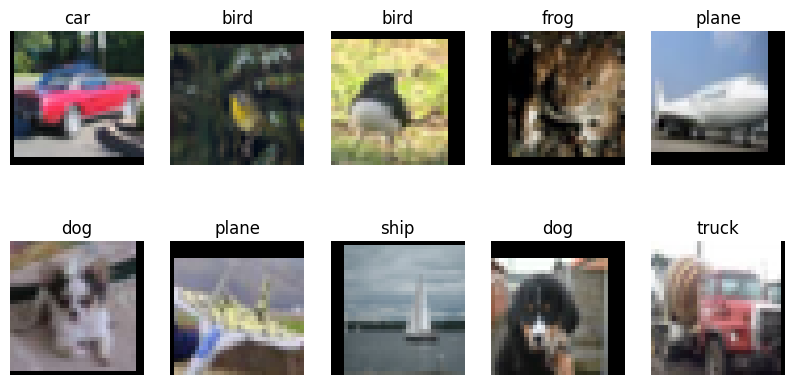

In [ ]:
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i in range(10):

    img = images[i].permute(1,2,0)

    img = img * torch.tensor(
        [0.2023,0.1994,0.2010]
    ) + torch.tensor(
        [0.4914,0.4822,0.4465]
    )

    axes[i//5][i%5].imshow(img)
    axes[i//5][i%5].set_title(classes[labels[i]])
    axes[i//5][i%5].axis("off")

plt.show()

#### Defining the Training Function (For All 4 models)

In [ ]:
def train_model(model, trainloader, testloader, epochs=20):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(trainloader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainloader)

        train_acc = 100 * correct / total

        model.eval()

        val_loss = 0

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in testloader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)

                total += labels.size(0)

                correct += predicted.eq(labels).sum().item()

        val_loss /= len(testloader)

        val_acc = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

#### Model 1: Baseline Shallow CNN

In [ ]:
# Defining the Model

class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))

        return self.fc2(x)

# Training the Model

model1 = BaselineCNN().to(device)

history1 = train_model(
    model1,
    trainloader,
    testloader,
    epochs=20
)

100%|██████████| 391/391 [01:25<00:00,  4.56it/s]


Epoch 1/20 | Train Acc: 44.22% | Val Acc: 57.21%


100%|██████████| 391/391 [01:22<00:00,  4.72it/s]


Epoch 2/20 | Train Acc: 56.10% | Val Acc: 60.04%


100%|██████████| 391/391 [01:25<00:00,  4.60it/s]


...

Epoch 18/20 | Train Acc: 76.28% | Val Acc: 76.45%


100%|██████████| 391/391 [01:22<00:00,  4.74it/s]


Epoch 19/20 | Train Acc: 76.86% | Val Acc: 77.09%


100%|██████████| 391/391 [01:22<00:00,  4.71it/s]


Epoch 20/20 | Train Acc: 77.19% | Val Acc: 76.65%


#### Model 2: Baseline + Batch Normalization

In [ ]:
# Defining the Model

class CNN_BN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = self.pool(
            F.relu(
                self.bn1(self.conv1(x))
            )
        )

        x = self.pool(
            F.relu(
                self.bn2(self.conv2(x))
            )
        )

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))

        return self.fc2(x)

# Training the Model

model2 = CNN_BN().to(device)

history2 = train_model(
    model2,
    trainloader,
    testloader,
    epochs=20
)

100%|██████████| 391/391 [01:40<00:00,  3.88it/s]


Epoch 1/20 | Train Acc: 44.46% | Val Acc: 58.05%


100%|██████████| 391/391 [01:44<00:00,  3.72it/s]


Epoch 2/20 | Train Acc: 57.15% | Val Acc: 63.29%


100%|██████████| 391/391 [01:44<00:00,  3.73it/s]


...

Epoch 18/20 | Train Acc: 74.10% | Val Acc: 74.54%


100%|██████████| 391/391 [01:51<00:00,  3.49it/s]


Epoch 19/20 | Train Acc: 74.23% | Val Acc: 76.41%


100%|██████████| 391/391 [01:46<00:00,  3.66it/s]


Epoch 20/20 | Train Acc: 74.35% | Val Acc: 74.11%


#### Model 3: Deeper CNN (without skip connections)

In [1]:
# Defining the Model

class DeepCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Linear(256,10)

    def forward(self,x):

        x = self.features(x)

        x = torch.flatten(x,1)

        return self.fc(x)

# Training the Model

model3 = DeepCNN().to(device)

history3 = train_model(
    model3,
    trainloader,
    testloader,
    epochs=20
)

NameError: name 'nn' is not defined

#### Model 4: Deep CNN with Residual (Skip) Connections

In [ ]:
# Defining the residual Block

class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self,x):

        identity = x

        out = F.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        out = self.bn2(
            self.conv2(out)
        )

        out += identity

        out = F.relu(out)

        return out

# Defining the Model

class ResNetSmall(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Conv2d(
            3,
            64,
            3,
            padding=1
        )

        self.bn = nn.BatchNorm2d(64)

        self.res1 = ResidualBlock(64)
        self.res2 = ResidualBlock(64)

        self.pool = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(64,10)

    def forward(self,x):

        x = F.relu(
            self.bn(
                self.conv(x)
            )
        )

        x = self.res1(x)

        x = self.pool(x)

        x = self.res2(x)

        x = self.pool(x)

        x = self.gap(x)

        x = torch.flatten(x,1)

        return self.fc(x)

# Training the Model

model4 = ResNetSmall().to(device)

history4 = train_model(
    model4,
    trainloader,
    testloader,
    epochs=20
)

#### Plotting Loss Curves

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history1["val_loss"], label="Baseline")
plt.plot(history2["val_loss"], label="BatchNorm")
plt.plot(history3["val_loss"], label="DeepCNN")
plt.plot(history4["val_loss"], label="Residual")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")

plt.legend()
plt.show()

#### Plotting Accuracy Curves

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history1["val_acc"], label="Baseline")
plt.plot(history2["val_acc"], label="BatchNorm")
plt.plot(history3["val_acc"], label="DeepCNN")
plt.plot(history4["val_acc"], label="Residual")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Validation Accuracy")

plt.legend()

plt.show()

#### Comparing the 4 models

In [ ]:
results = {
    "Baseline CNN": max(history1["val_acc"]),
    "CNN + BatchNorm": max(history2["val_acc"]),
    "Deep CNN": max(history3["val_acc"]),
    "Residual CNN": max(history4["val_acc"])
}

for model, acc in results.items():
    print(f"{model:20s} : {acc:.2f}%")